# Parameters

In [2]:
import sys
import os
from pathlib import Path
import pandas as pd

# ===== CONFIGURAÇÃO DE CAMINHOS =====
current_notebook = Path.cwd()  
project_root = current_notebook.parent.parent 

# Adiciona o diretório raiz ao sys.path
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Adiciona o diretório Modules ao sys.path
modules_dir = project_root / "Modules"
if str(modules_dir) not in sys.path:
    sys.path.insert(0, str(modules_dir))

# ===== IMPORTS DOS MÓDULOS =====
import Modules.ClusterHDBSCANModule as cluster
import Modules.FutureAnalysisModule as fa
from Modules.config import CONFIG

# ===== CONFIGURAÇÕES DO PROJETO =====
DATAPATH = CONFIG["datapath"]
COVID_TRAIN_DATA_FILE = CONFIG["covid_train_data_file"]
COVID_TEST_DATA_FILE = CONFIG["covid_test_data_file"]
FUTURE_DATA_FILE = CONFIG["future_data_file"]

FIGSIZE_CLUSTER_HEATMAP = CONFIG["figsize_cluster_heatmap"]
FIGSIZE_FUTURE_HEATMAP = CONFIG["figsize_future_heatmap"]
IMAGES_SAVE_PATH = CONFIG["image_save_path"]

TRIALS_OPTUNA = 250

# Import data

In [3]:
# ===== CARREGAMENTO DOS DADOS =====
data_folder = current_notebook / DATAPATH

covid_train = pd.read_csv(data_folder / COVID_TRAIN_DATA_FILE)
covid_test = pd.read_csv(data_folder / COVID_TEST_DATA_FILE)
future_data = pd.read_csv(data_folder / FUTURE_DATA_FILE)

# Feature engineering: morte após a internação
covid_train['died_after'] = ((covid_train['died'] == 1) & (covid_train['died_in_stay'] == 0)).astype(int)
covid_test['died_after'] = ((covid_test['died'] == 1) & (covid_test['died_in_stay'] == 0)).astype(int)
future_data['died_after'] = ((future_data['died'] == 1) & (future_data['died_in_stay'] == 0)).astype(int)

In [4]:
data_covid = pd.concat([covid_train, covid_test], axis=0)
data_covid = data_covid.sample(frac=1, random_state=42).reset_index(drop=True)

# Mice Data

In [5]:
categorical_features = [
            "myocardial_infarct",
            "congestive_heart_failure",
            "peripheral_vascular_disease",
            "cerebrovascular_disease",
            "dementia",
            "chronic_pulmonary_disease",
            "rheumatic_disease",
            "peptic_ulcer_disease",
            "mild_liver_disease",
            "diabetes_without_cc",
            "diabetes_with_cc",
            "paraplegia",
            "renal_disease",
            "malignant_cancer",
            "severe_liver_disease",
            "metastatic_solid_tumor",
            "aids",
            "gender_M",
            "died_in_stay",
            "died_after",
            "died",
            "COVID"
        ]

In [6]:
featuresNotConsidered = ['died', 'died_in_stay', 'died_after', 'COVID', 'subject_id', 'hadm_id']

In [7]:
helper = cluster.HDBSCANClusterHelper(data=data_covid, featuresNotConsidered=featuresNotConsidered)

## Find best hyperparameters for DBSCAN - cluster_selection_method: 'eom'

In [8]:
param = {
    "min_cluster_size": {"min": 2, "max": 50},
    "min_samples": {"min": 1, "max": 50}
}

### DBCV

In [9]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# pca_dbcv_df, pca_dbcv_param, pca_dbcv_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dbcv",
#     suffix="pca",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'PCA', 'dimensions': 30}
# )

In [10]:
pca_dbcv_param = {'min_cluster_size': 3, 'min_samples': 3}

In [11]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# ae_dbcv_df, ae_dbcv_param, ae_dbcv_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dbcv",
#     suffix="ae",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'AE', 'dimensions': 10}
# )

In [12]:
ae_dbcv_param = {'min_cluster_size': 5, 'min_samples': 6}

### DISCO

In [13]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# pca_disco_df, pca_disco_param, pca_disco_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="disco",
#     suffix="pca",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'PCA', 'dimensions': 30}
# )

In [14]:
pca_disco_param = {'min_cluster_size': 44, 'min_samples': 28}

In [15]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# ae_disco_df, ae_disco_param, ae_disco_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="disco",
#     suffix="ae",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'AE', 'dimensions': 10}
# )

In [16]:
ae_disco_param = {'min_cluster_size': 5, 'min_samples': 40}

### DSI

In [17]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# pca_dsi_df, pca_dsi_param, pca_dsi_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dsi",
#     suffix="pca",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'PCA', 'dimensions': 30}
# )

In [18]:
pca_dsi_param = {'min_cluster_size': 2, 'min_samples': 4}

In [19]:
# os.environ["PYTHONWARNINGS"] = "ignore"
# ae_dsi_df, ae_dsi_param, ae_dsi_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="dsi",
#     suffix="ae",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'AE', 'dimensions': 10}
# )

In [20]:
ae_dsi_param = {'min_cluster_size': 2, 'min_samples': 10}

### Silhouette

In [21]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# pca_silhouette_df, pca_silhouette_param, pca_silhouette_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="silhouette",
#     suffix="pca",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'PCA', 'dimensions': 30}
# )

In [22]:
pca_silhouette_param = {'min_cluster_size': 13, 'min_samples': 1}

In [23]:
# os.environ['PYTHONWARNINGS'] = 'ignore'
# ae_silhouette_df, ae_silhouette_param, ae_silhouette_best = helper.optunaGridSearch(
#     parameters=param, 
#     n_trials=TRIALS_OPTUNA, 
#     saveStorage=True, 
#     metric="silhouette",
#     suffix="ae",
#     restrictMinsizeCluster=2,
#     restrictMaxsizeCluster=80,
#     dimensionality_reduction = {'method': 'AE', 'dimensions': 10}
# )

In [24]:
ae_silhouette_param = {'min_cluster_size': 9, 'min_samples': 40}

## Metrics

### PCA

In [25]:
helper.clustering(
    min_cluster_size=pca_dbcv_param["min_cluster_size"],
    min_samples=pca_dbcv_param["min_samples"],
    dimensionality_reduction={"method": "PCA", "dimensions": 30},
)
helper.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.281,
 'dbcv': 0.7448576778858761,
 'dsi': np.float64(0.362),
 'disco': np.float64(-0.3125217735802071)}

In [26]:
helper.clustering(
    min_cluster_size=pca_disco_param["min_cluster_size"],
    min_samples=pca_disco_param["min_samples"],
    dimensionality_reduction={"method": "PCA", "dimensions": 30},
)
helper.getMetrics()

{'silhouette': -1, 'dbcv': 0.0, 'dsi': 0, 'disco': np.float64(-1.0)}

In [27]:
helper.clustering(
    min_cluster_size=pca_dsi_param["min_cluster_size"],
    min_samples=pca_dsi_param["min_samples"],
    dimensionality_reduction={"method": "PCA", "dimensions": 30},
)
helper.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.376,
 'dbcv': 0.6852449860237603,
 'dsi': np.float64(0.57),
 'disco': np.float64(-0.40997709345234185)}

In [28]:
helper.clustering(
    min_cluster_size=pca_silhouette_param["min_cluster_size"],
    min_samples=pca_silhouette_param["min_samples"],
    dimensionality_reduction={"method": "PCA", "dimensions": 30},
)
helper.getMetrics()

/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.327,
 'dbcv': -0.3531759811530858,
 'dsi': np.float64(0.222),
 'disco': np.float64(-0.5508250375403968)}

### Autoencoder

In [29]:
helper.clustering(
    min_cluster_size=ae_dbcv_param["min_cluster_size"],
    min_samples=ae_dbcv_param["min_samples"],
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:27<00:00,  3.67it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.033,
 'dbcv': 0.7833065958884549,
 'dsi': np.float64(0.16),
 'disco': np.float64(-0.23652757975193217)}

In [34]:
helper.clustering(
    min_cluster_size=ae_disco_param["min_cluster_size"],
    min_samples=ae_disco_param["min_samples"],
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:26<00:00,  3.74it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': 0.199,
 'dbcv': 0.6560336587056128,
 'dsi': np.float64(0.16),
 'disco': np.float64(0.23076913708110547)}

In [31]:
helper.clustering(
    min_cluster_size=ae_dsi_param["min_cluster_size"],
    min_samples=ae_dsi_param["min_samples"],
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:28<00:00,  3.56it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.539,
 'dbcv': 0.3374066134425654,
 'dsi': np.float64(0.413),
 'disco': np.float64(-0.7172901455325629)}

In [32]:
helper.clustering(
    min_cluster_size=pca_silhouette_param["min_cluster_size"],
    min_samples=pca_silhouette_param["min_samples"],
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.getMetrics()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:26<00:00,  3.72it/s]


/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)
/Users/gabrielleite/Backup/Mestrado/EnvMestrado/lib/python3.11/site-packages/dbcv/core.py:91: RuntimeWarning: divide by zero encountered in power
  np.power(core_dists, -1.0 / d, out=core_dists)


{'silhouette': -0.184,
 'dbcv': -0.3852778378439401,
 'dsi': np.float64(0.106),
 'disco': np.float64(-0.46174929916614843)}

## Best Result - DISCO - Autoencoder

In [ ]:
best_param = ae_disco_param

In [ ]:
helper.clustering(
    min_cluster_size=best_param["min_cluster_size"],
    min_samples=best_param["min_samples"],
    dimensionality_reduction={"method": "AE", "dimensions": 10},
)
helper.getMetrics()

{'silhouette': -0.281,
 'dbcv': 0.7448576778858761,
 'dsi': np.float64(0.362),
 'disco': np.float64(-0.3125217735802071)}

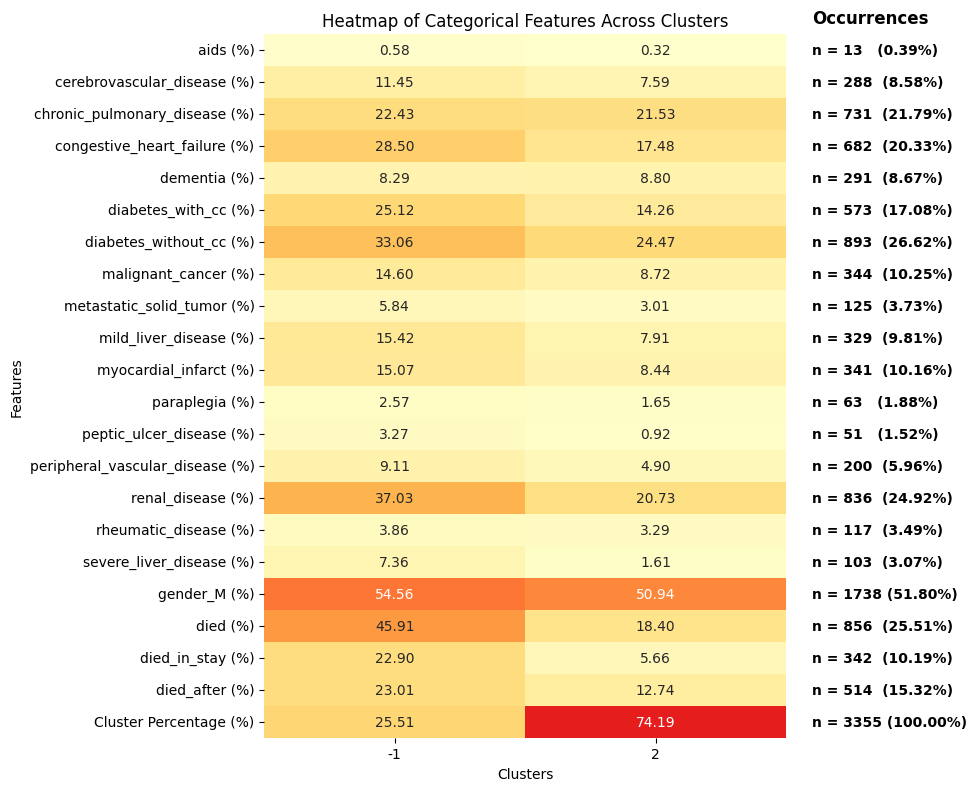

In [ ]:
helper.heatmapClustersCategorical(figsize=FIGSIZE_CLUSTER_HEATMAP, savepath=IMAGES_SAVE_PATH + "hdbscan-dr-categorical")

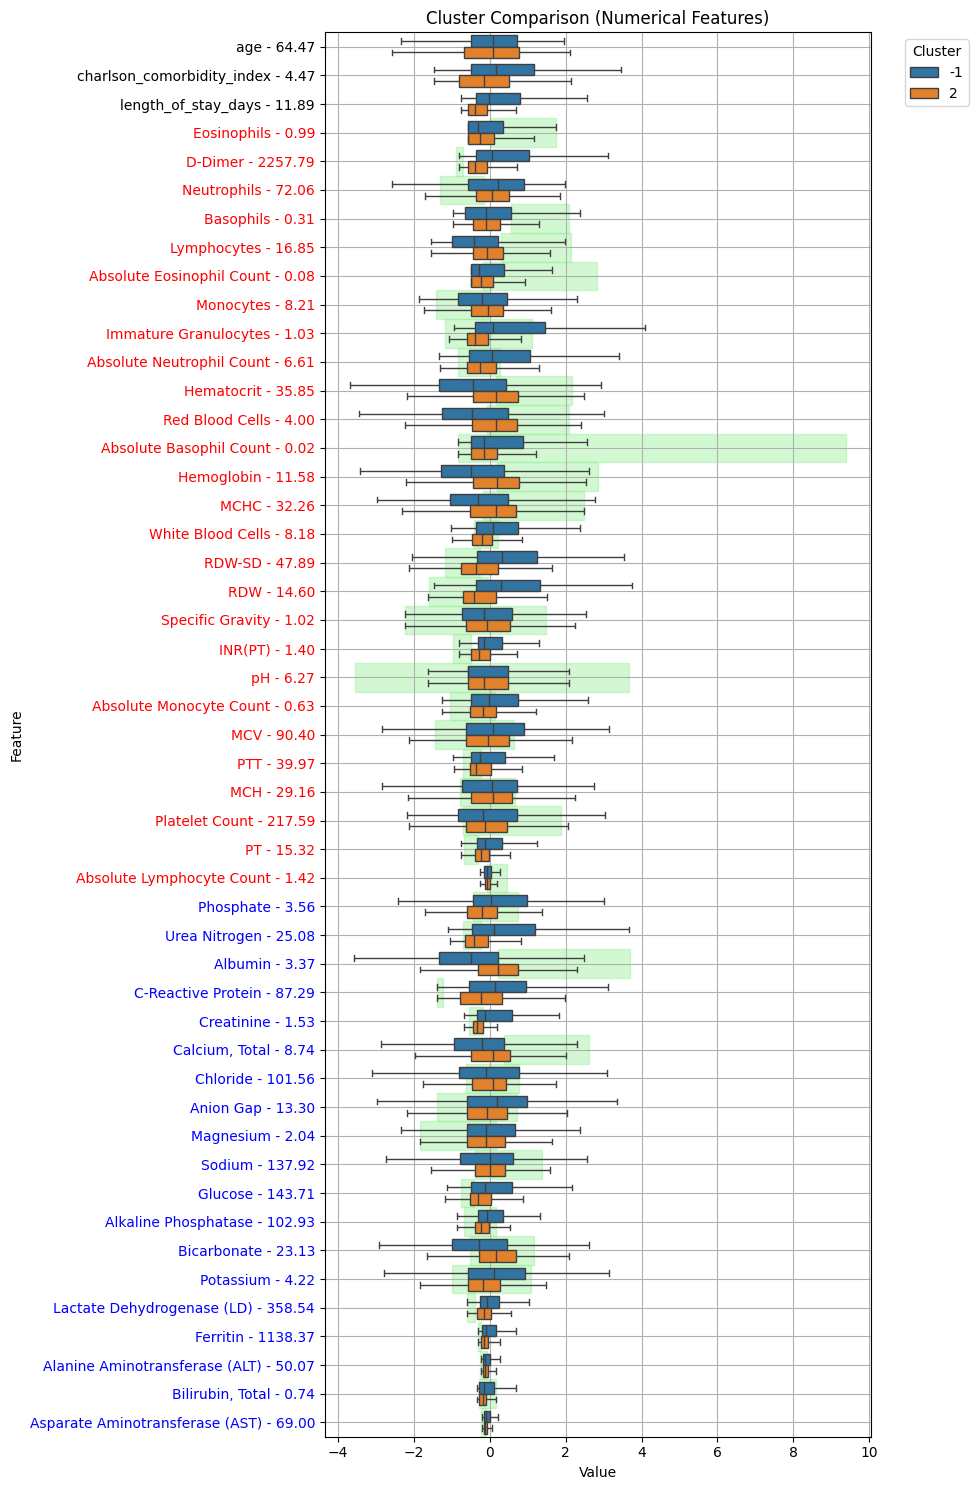

[]

In [ ]:
helper.showClusterCompareNumerical(
    scaled="standard",
    topFeatures=-1,
    max_features=-1,
    figsize=(10, 15),
    savepath=IMAGES_SAVE_PATH + "hdbscan-dr-numerical"
)

In [ ]:
selectedClusters = [-1, 2]

In [ ]:
helper.setClusteredAutoencoder()

Autoencoder is not fitted yet, will be pretrained.
Start training with clustering loss.
Epoch: 100%|██████████| 100/100 [00:25<00:00,  3.88it/s]


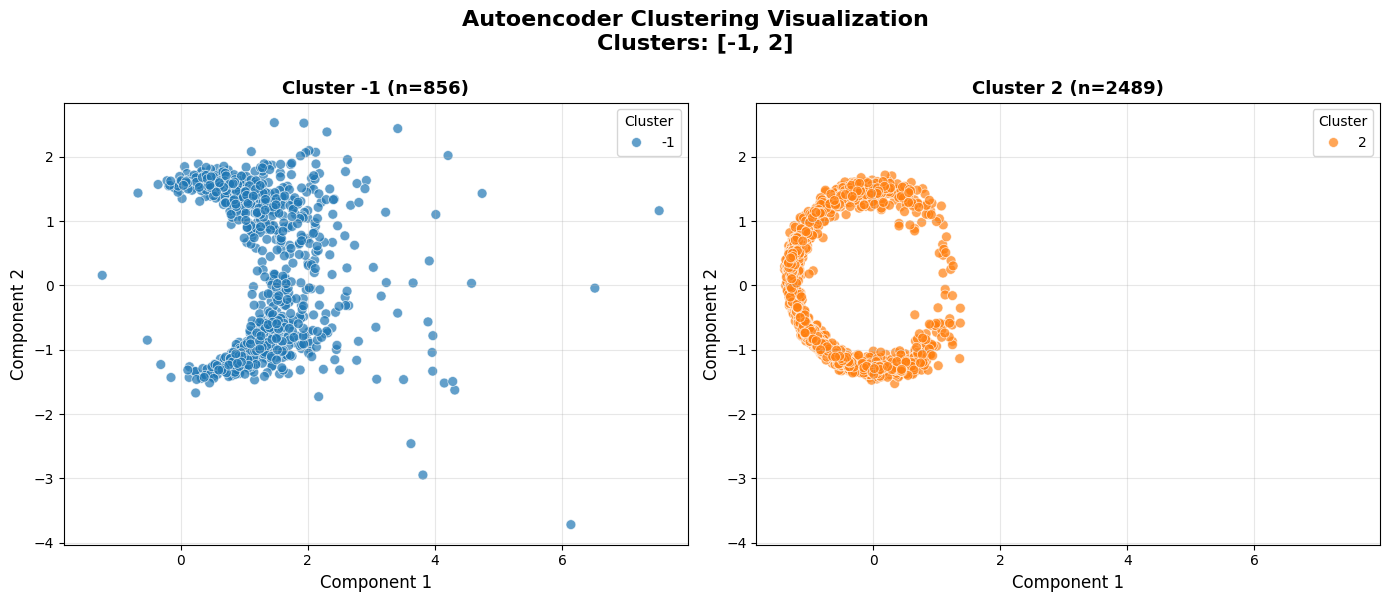

In [ ]:
helper.showClusteredAutoencoder(selectedClusters=selectedClusters, savepath=IMAGES_SAVE_PATH + "hdbscan-autoencoder-dr")

##### Future data


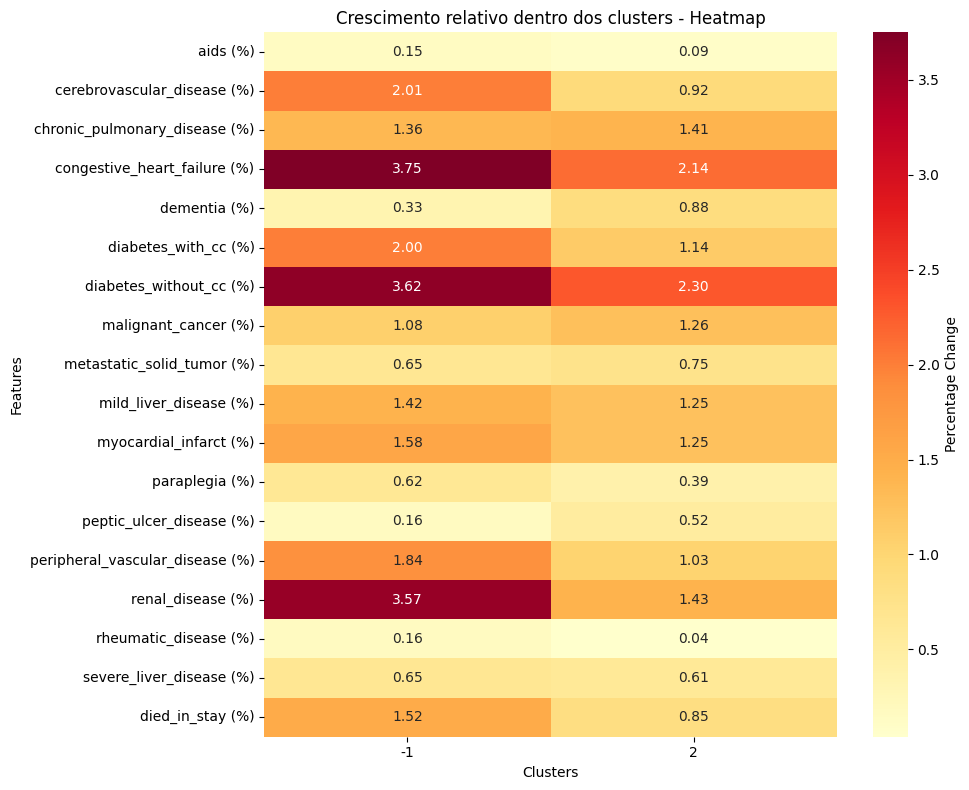

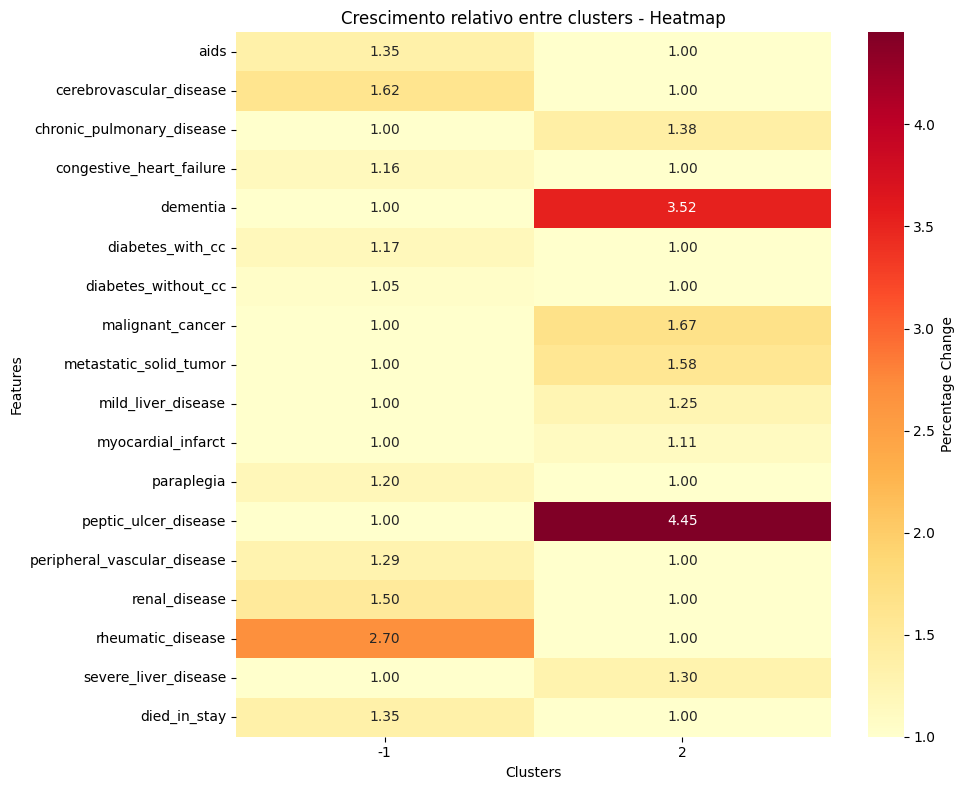

In [ ]:
future_helper = fa.FutureAnalysisHelper(helper.clusteredData, future_data)
future_helper.insertClustersInFutureData(onlyFirstAdmission=True)
delta = future_helper.getDeltaClusters(percentage=True, metric="interno")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "hdbscan-dr-dbcv-interno", selectedClusters=selectedClusters,
    metric="interno"
)
delta = future_helper.getDeltaClusters(percentage=True, metric="externo")
future_helper.showDeltaHeatmap(
    figsize=FIGSIZE_FUTURE_HEATMAP,
    savepath=IMAGES_SAVE_PATH + "hdbscan-dr-dbcv-externo", selectedClusters=selectedClusters,
    metric="externo"
)

In [ ]:
future_helper.getMeanReadmission()

{'Mean readmission Cluster -1': 2.57,
 'Mean readmission Cluster 0': 2.0,
 'Mean readmission Cluster 1': 2.0,
 'Mean readmission Cluster 2': 2.22,
 'Overall Mean readmission': 2.31}

In [ ]:
future_helper.getMeanDaysGap()

{'Mean days gap Cluster -1': 116.42,
 'Mean days gap Cluster 0': 30.81,
 'Mean days gap Cluster 1': 144.2,
 'Mean days gap Cluster 2': 131.66,
 'Overall Mean days gap': 127.49}

In [ ]:
future_helper.getMortalityRates(onlyFirstAdmission=True)

{'Mortality rate Cluster -1': 0.05,
 'Mortality rate Cluster 0': 0.0,
 'Mortality rate Cluster 1': 0.0,
 'Mortality rate Cluster 2': 0.14,
 'Overall Mortality rate': 0.09}